In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_qsphere

# Using Aer's statevector simulator for phase verification
simulator = Aer.get_backend('aer_simulator')

In [ ]:
def apply_shared_entangler(qc, q0, q1):
    """The core entangling circuit, reused for all four Bell states."""
    qc.h(q0)
    qc.cx(q0, q1)
    return qc

In [3]:
def create_bell_circuit(state_label):
    qc = QuantumCircuit(2, 2)
    
    # Basis Preparation
    if state_label == 'phi_plus':   pass 
    elif state_label == 'phi_minus': qc.x(0)
    elif state_label == 'psi_plus':  qc.x(1)
    elif state_label == 'psi_minus': qc.x(0); qc.x(1)
        
    # Shared Entangler
    apply_shared_entangler(qc, 0, 1)
    
    # Add measurement for the histogram layer
    qc.measure(range(2), range(2))
    return qc

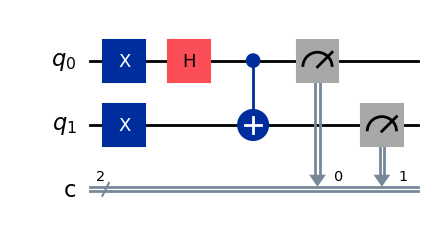

In [6]:
qc.draw('mpl', filename='circuit.png')

Results for phi_plus: {'11': 537, '00': 487}


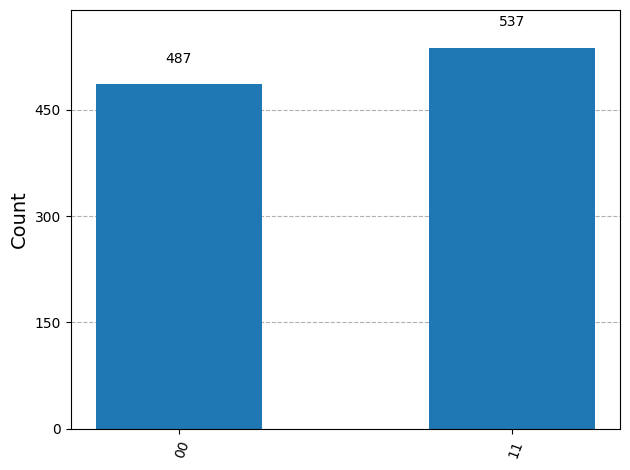

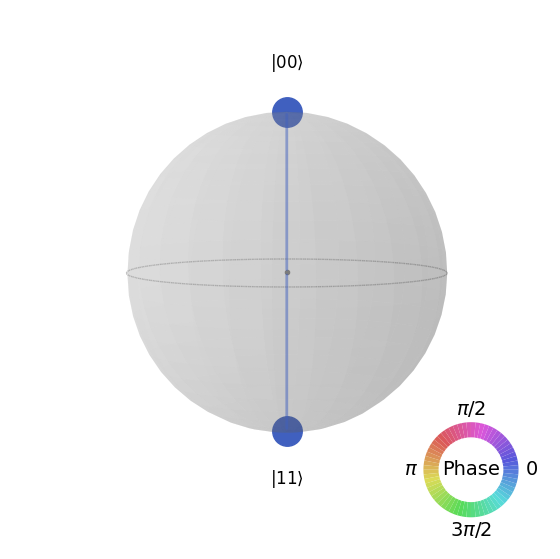

Results for phi_minus: {'00': 515, '11': 509}


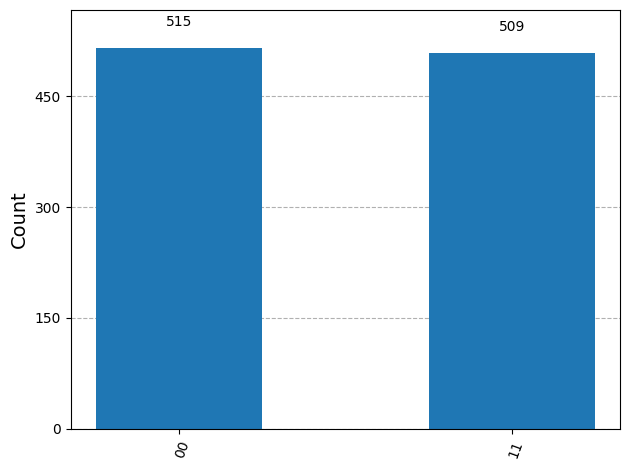

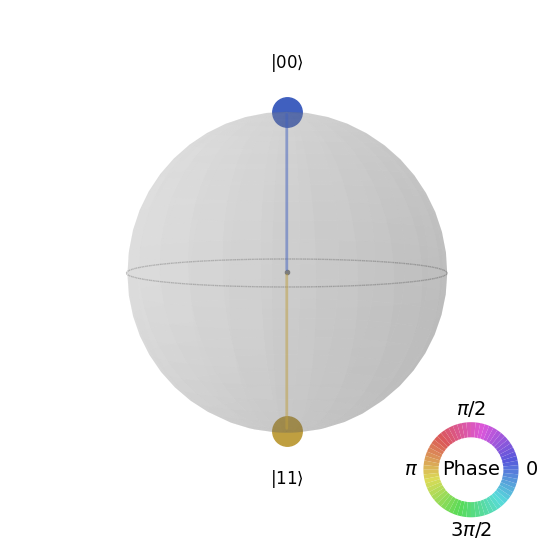

Results for psi_plus: {'10': 516, '01': 508}


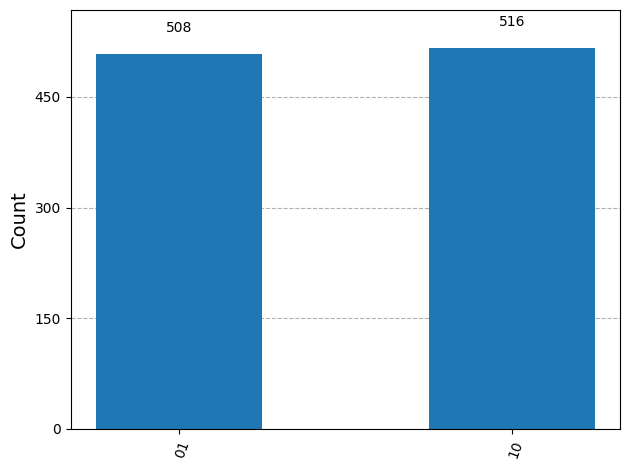

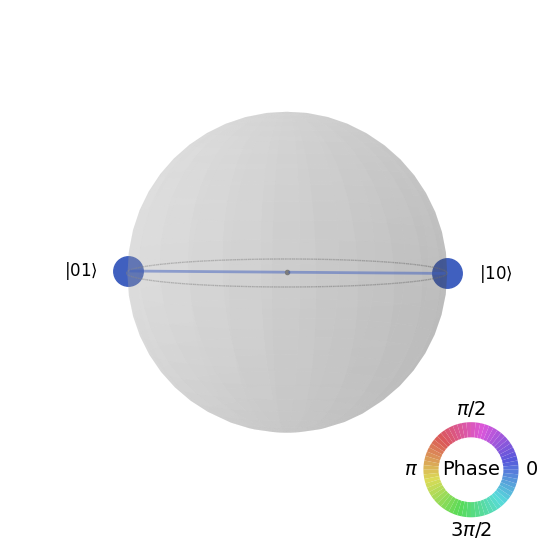

Results for psi_minus: {'01': 508, '10': 516}


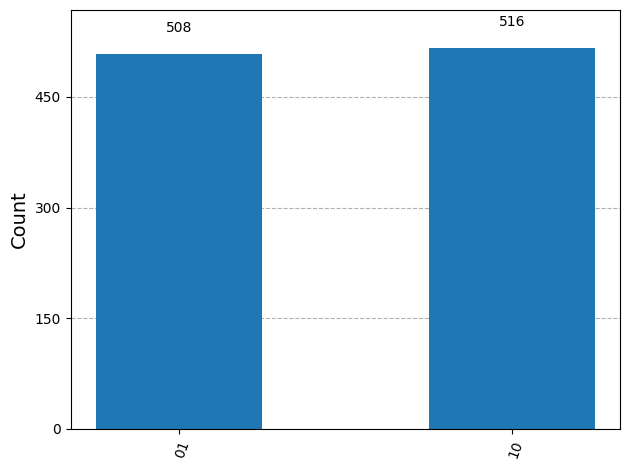

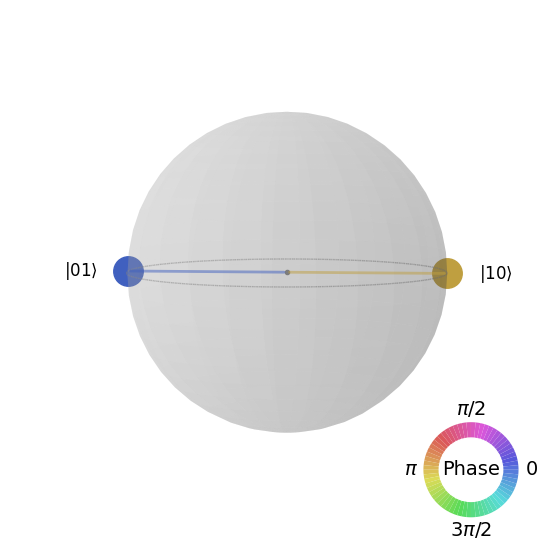

In [4]:
states = ['phi_plus', 'phi_minus', 'psi_plus', 'psi_minus']

for label in states:
    # 1. Histogram Layer
    qc = create_bell_circuit(label)
    result = simulator.run(transpile(qc, simulator), shots=1024).result()
    counts = result.get_counts()
    print(f"Results for {label}: {counts}")
    display(plot_histogram(counts))
    
    # 2. Statevector Layer (for Q-sphere/Phase)
    qc_no_measure = create_bell_circuit(label).remove_final_measurements(inplace=False)
    state = Statevector.from_instruction(qc_no_measure)
    # Using plot_state_qsphere (ensure you have the import for this)
    display(plot_state_qsphere(state))